# PEL 309 - Data Science - Paper

Esse arquivo contém as análises e experimentos correspondentes ao trabalho da matéria PEL 309.

In [2]:
import os
import pandas as pd
import numpy as np
import sklearn
import kagglehub
import seaborn as sns
import matplotlib
from matplotlib import pyplot as plt

In [3]:
# Download latest version
path = kagglehub.dataset_download("zahranusratt/smartphone-usage-and-addiction-analysis-dataset")

print("Path to dataset files:", path)

Path to dataset files: /home/melo/.cache/kagglehub/datasets/zahranusratt/smartphone-usage-and-addiction-analysis-dataset/versions/1


In [4]:
df = pd.read_csv(f"{path}/{os.listdir(path)[0]}")

In [5]:
print(df.columns)

Index(['transaction_id', 'user_id', 'age', 'gender', 'daily_screen_time_hours',
       'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours',
       'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time',
       'stress_level', 'academic_work_impact', 'addiction_level',
       'addicted_label'],
      dtype='str')


In [11]:
df['addicted_label'].value_counts()

addicted_label
1    5308
0    2192
Name: count, dtype: int64

In [6]:
res = df['addicted_label'].value_counts()
ct = df['addicted_label'].count() 

false_count = res[0]/ct
true_count = res[1]/ct

false_count, true_count

(np.float64(0.2922666666666667), np.float64(0.7077333333333333))

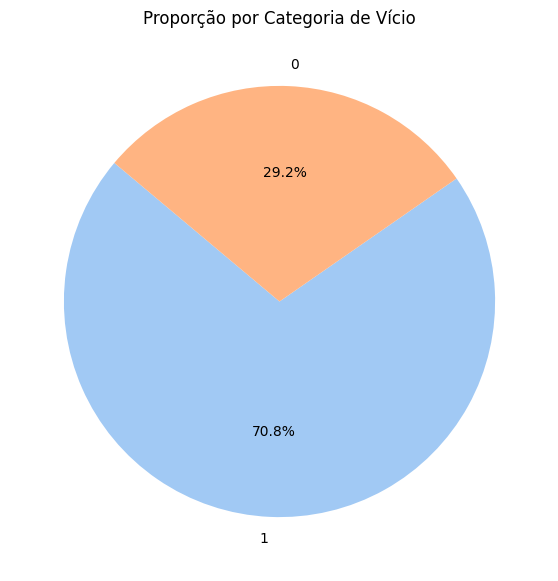

In [7]:
# Calculando a contagem de cada label
label_counts = df['addicted_label'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))

plt.title('Proporção por Categoria de Vício')
plt.show()

/tmp/ipykernel_43696/2760656736.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='addicted_label', palette='viridis', order=df['addicted_label'].value_counts().index[::-1])


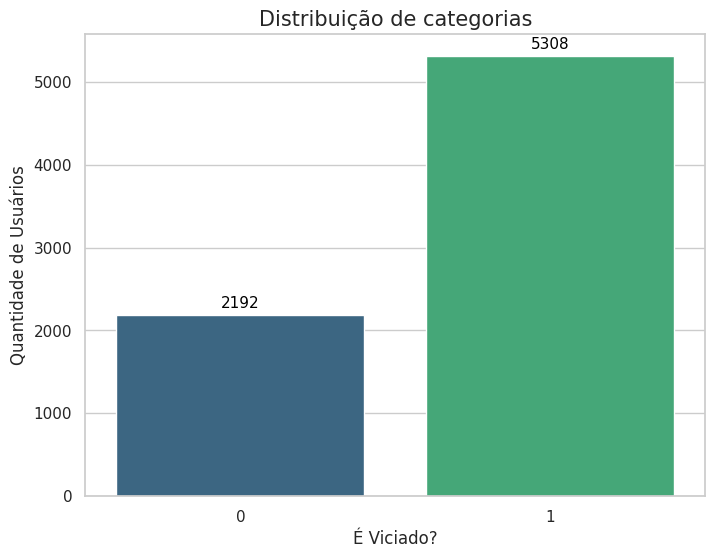

In [13]:
# Configurando o estilo visual
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 6))

ax = sns.countplot(data=df, x='addicted_label', palette='viridis', order=df['addicted_label'].value_counts().index[::-1])

# Adicionando o título e rótulos
plt.title('Distribuição de categorias', fontsize=15)
plt.xlabel('É Viciado?', fontsize=12)
plt.ylabel('Quantidade de Usuários', fontsize=12)

# Dica: Adicionar os valores em cima das barras
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='baseline', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()